<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 02 — Solving Linear Programs with Python
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>


## Learning Objectives

By the end of this session, students will be able to:

1. Understand why we need optimization solvers.
2. Implement a Linear Programming (LP) model in Python.
3. Use the PuLP library to solve LP problems.
4. Interpret optimal solutions and slack values.
5. Connect the solver output to the geometry of LP (vertices).
6. Build scalable LP models using sets and loops.

---

## From Modeling to Solving

Last session, we:

- Defined decision variables
- Built objective functions
- Defined constraints
- Visualized the feasible region

Today we take the next step:

> Let Python find the optimal solution automatically.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Why Do We Need a Solver?
  </h2>
</div>


In the previous notebook, we manually evaluated some candidate solutions.

But in real problems:

- The number of possible solutions can be extremely large.
- Manual enumeration is impossible.
- Even checking all integer combinations can take years.

Instead, we use mathematical optimization algorithms.

For Linear Programming, the most famous algorithm is:

> **Simplex Method**

Today, we will not implement Simplex ourselves.

Instead, we will use a solver through Python.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Introduction to PuLP
  </h2>
</div>

PuLP is a Python library for modeling and solving Linear Programming problems.

It allows us to:

- Define variables
- Define objective function
- Define constraints
- Call a solver
- Read results

---

If PuLP is not installed, run:


In [3]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Solving the Production Problem
  </h2>
</div>


Recall the model:

Maximize:
    
    30A + 20B

Subject to:

    2A + B ≤ 100
    A + B ≤ 80
    A ≥ 0
    B ≥ 0

We now implement this model in PuLP.


In [4]:
model = pulp.LpProblem("Production_Optimization", pulp.LpMaximize)

In [5]:
A = pulp.LpVariable('A', lowBound=0)
B = pulp.LpVariable('B', lowBound=0)

In [6]:
model += 30*A + 20*B, "Total_Profit"

In [7]:
model += 2*A + B <= 100, "Machine_Constraint"
model += A + B <= 80, "Material_Constraint"

In [25]:
model

Production_Optimization:
MAXIMIZE
30*A + 20*B + 0
SUBJECT TO
Machine_Constraint: 2 A + B <= 100

Material_Constraint: A + B <= 80

VARIABLES
A Continuous
B Continuous

In [8]:
model.solve()

print("Status:", pulp.LpStatus[model.status])

Status: Optimal


In [9]:
print("Optimal A =", A.varValue)
print("Optimal B =", B.varValue)
print("Maximum Profit =", pulp.value(model.objective))

Optimal A = 20.0
Optimal B = 60.0
Maximum Profit = 1800.0


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Slack Variables
  </h2>
</div>


Slack tells us how much unused resource remains.

Slack = RHS - LHS at optimal solution.

We can compute slack manually.


In [11]:
machine_slack = 100 - (2*A.varValue + B.varValue)
material_slack = 80 - (A.varValue + B.varValue)

print("Machine Slack =", machine_slack)
print("Material Slack =", material_slack)

Machine Slack = 0.0
Material Slack = 0.0


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. Visualizing the Optimal Solution
  </h2>
</div>

Let us plot:

- Constraint lines
- Feasible region
- Optimal solution

This shows that the optimal solution lies at a vertex.

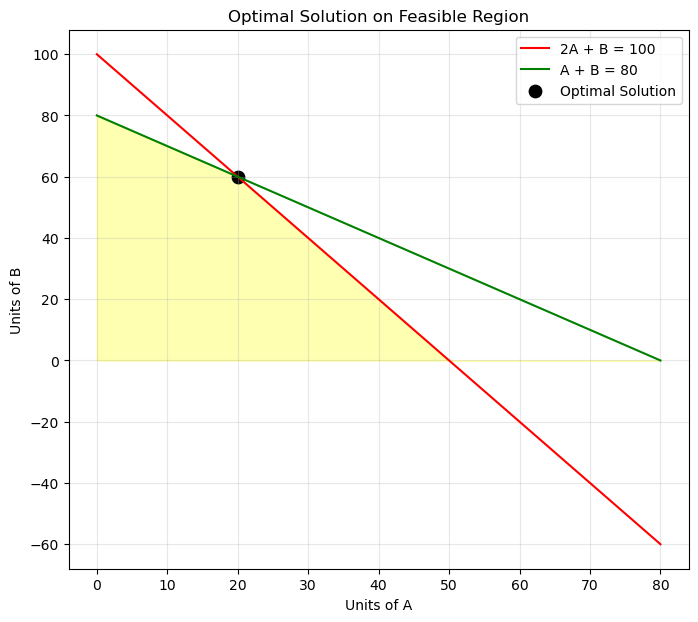

In [23]:
A_vals = np.linspace(0, 80, 400)
machine_line = 100 - 2*A_vals
material_line = 80 - A_vals

plt.figure(figsize=(8,7))

plt.plot(A_vals, machine_line, label="2A + B = 100", color='red')
plt.plot(A_vals, material_line, label="A + B = 80", color='green')

# Shade feasible region
A_fill = np.linspace(0,80,400)
B_fill = np.minimum(100 - 2*A_fill, 80 - A_fill)
B_fill[B_fill < 0] = 0

plt.fill_between(A_fill, B_fill, alpha=0.3, color='yellow')

# Optimal point
plt.scatter(A.varValue, B.varValue, color="black", s=80, label="Optimal Solution")

plt.xlabel("Units of A")
plt.ylabel("Units of B")
plt.legend()
plt.title("Optimal Solution on Feasible Region")

plt.grid(alpha=0.3)
plt.show()


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. A More Realistic Example
  </h2>
</div>

Now we build a slightly more realistic production model.

Products: **A, B, C**  
Resources: **Machine, Labor**

We will build the model using sets and loops.


In [13]:
products = ['A', 'B', 'C']
profit = {'A': 30, 'B': 20, 'C': 25}

machine_req = {'A': 2, 'B': 1, 'C': 1}
labor_req = {'A': 1, 'B': 2, 'C': 2}

capacity = {'machine': 100, 'labor': 90}

In [14]:
model2 = pulp.LpProblem("Production_3Products", pulp.LpMaximize)

x = pulp.LpVariable.dicts("Production", products, lowBound=0)
# Objective
model2 += pulp.lpSum(profit[p] * x[p] for p in products)

# Machine constraint
model2 += pulp.lpSum(machine_req[p] * x[p] for p in products) <= capacity['machine']
# Labor constraint
model2 += pulp.lpSum(labor_req[p] * x[p] for p in products) <= capacity['labor']

model2.solve()

print("Status:", pulp.LpStatus[model2.status])

Status: Optimal


In [15]:
for p in products:
    print(p, "=", x[p].varValue)

print("Maximum Profit =", pulp.value(model2.objective))

A = 36.666667
B = 0.0
C = 26.666667
Maximum Profit = 1766.6666850000001


Notice something important:

We did NOT hardcode variables individually.

Instead, we:

- Used a set of products
- Used dictionaries
- Used loops

This means:

If tomorrow we have 50 products, the model structure does not change.

This is how real optimization models are built in practice.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    7. Case Study: Production Planning for a Food Company
  </h2>
</div>

A food manufacturing company produces several packaged products:

- Granola Bars
- Protein Bars
- Oatmeal Packs
- Trail Mix
- Nut Mix
- Energy Bites

Each product requires different amounts of:

- Machine time
- Labor
- Raw ingredients
- Packaging

The company has limited resources available each day.

The goal is to determine how much of each product should be produced
in order to **maximize total profit** while respecting all resource limits.

---

## Products

| Product | Profit ($) |
|-------|-------|
Granola Bar | 4  
Protein Bar | 5  
Oatmeal Pack | 3  
Trail Mix | 6  
Nut Mix | 5  
Energy Bites | 7  

---

## Resource Requirements

### Machine Time (minutes per unit)

| Product | Machine Time |
|------|------|
Granola Bar | 3  
Protein Bar | 4  
Oatmeal Pack | 2  
Trail Mix | 5  
Nut Mix | 4  
Energy Bites | 6  

---

### Labor Time (minutes per unit)

| Product | Labor |
|------|------|
Granola Bar | 2  
Protein Bar | 3  
Oatmeal Pack | 2  
Trail Mix | 4  
Nut Mix | 3  
Energy Bites | 5  

---

### Ingredient Consumption (kg per unit)

| Product | Ingredients |
|------|------|
Granola Bar | 1.2  
Protein Bar | 1.5  
Oatmeal Pack | 0.8  
Trail Mix | 1.8  
Nut Mix | 1.6  
Energy Bites | 2.0  

---

### Packaging Requirement (boxes per unit)

| Product | Packaging |
|------|------|
Granola Bar | 1  
Protein Bar | 1  
Oatmeal Pack | 1  
Trail Mix | 1  
Nut Mix | 1  
Energy Bites | 1  

---

## Available Resources

Machine time: **1200 minutes/day**

Labor time: **900 minutes/day**

Ingredients: **500 kg/day**

Packaging boxes: **400 units/day**

---

## Demand Constraints

Due to market demand:

Granola Bar ≤ 150  
Protein Bar ≤ 120  
Oatmeal Pack ≤ 200  
Trail Mix ≤ 100  
Nut Mix ≤ 140  
Energy Bites ≤ 90

---

## Objective

Maximize total daily profit.


## Solution

### Import Packages

In [26]:
import pulp
import pandas as pd

### Define problem components (**Data** and **Model**) 

In [27]:
products = [
    "Granola",
    "ProteinBar",
    "Oatmeal",
    "TrailMix",
    "NutMix",
    "EnergyBites"
]

profit = {
    "Granola":4,
    "ProteinBar":5,
    "Oatmeal":3,
    "TrailMix":6,
    "NutMix":5,
    "EnergyBites":7
}

machine = {
    "Granola":3,
    "ProteinBar":4,
    "Oatmeal":2,
    "TrailMix":5,
    "NutMix":4,
    "EnergyBites":6
}

labor = {
    "Granola":2,
    "ProteinBar":3,
    "Oatmeal":2,
    "TrailMix":4,
    "NutMix":3,
    "EnergyBites":5
}

ingredients = {
    "Granola":1.2,
    "ProteinBar":1.5,
    "Oatmeal":0.8,
    "TrailMix":1.8,
    "NutMix":1.6,
    "EnergyBites":2.0
}

demand = {
    "Granola":150,
    "ProteinBar":120,
    "Oatmeal":200,
    "TrailMix":100,
    "NutMix":140,
    "EnergyBites":90
}

In [28]:
model = pulp.LpProblem("FoodProduction", pulp.LpMaximize)

x = pulp.LpVariable.dicts("prod", products, lowBound=0)

### Objective function

In [29]:
model += pulp.lpSum(profit[p]*x[p] for p in products)

### Constraints

In [30]:
# Machine
model += pulp.lpSum(machine[p]*x[p] for p in products) <= 1200

# Labor
model += pulp.lpSum(labor[p]*x[p] for p in products) <= 900

# Ingredients
model += pulp.lpSum(ingredients[p]*x[p] for p in products) <= 500

# Packaging
model += pulp.lpSum(x[p] for p in products) <= 400

# Demand limits
for p in products:
    model += x[p] <= demand[p]

### Solve

In [31]:
model.solve()

print("Status:", pulp.LpStatus[model.status])

Status: Optimal


### Results

In [35]:
results = {}

for p in products:
    results[p] = x[p].varValue

df = pd.DataFrame.from_dict(results, orient="index", columns=["Production"])
df

,Production
Granola,150.0
ProteinBar,120.0
Oatmeal,75.0
TrailMix,0.0
NutMix,30.0
EnergyBites,0.0


In [33]:
print("Maximum Profit =", pulp.value(model.objective))

Maximum Profit = 1575.0


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    8. Exercises
  </h2>
</div>

Use the model (Food Company Problem) you implemented to answer the following questions.

---

## Exercise 1 — Capacity Change

Suppose the machine capacity decreases from

1200 minutes → 1000 minutes

1. Modify the model.
2. Solve again.
3. Which product's production decreases the most?
4. What is the new optimal profit?

---

## Exercise 2 — New Market Opportunity

The marketing department reports that **Energy Bites** can now be sold with a higher margin.

New profit:

Energy Bites profit = 9

1. Update the profit parameter.
2. Resolve the model.
3. How does the production plan change?
4. Which product loses production because of this change?

---

## Exercise 3 — Packaging Shortage

Due to supply chain issues, the number of packaging boxes is reduced.

New packaging capacity:

400 → 300

1. Update the constraint.
2. Solve the model again.
3. Which product should the company prioritize?
4. Which product is reduced the most?

---

## Exercise 4 — Adding a New Product

The company plans to introduce a new product:

**Organic Protein Snack**

Profit: 8  
Machine time: 5  
Labor time: 4  
Ingredients: 1.7  
Maximum demand: 80

Tasks:

1. Add the new product to the model.
2. Update all data dictionaries.
3. Solve the new model.
4. Does the company produce this new product? Why or why not?

---

## Exercise 5 — Identifying the Bottleneck

After solving the base model:

1. Compute how much of each resource is used:
   - Machine time
   - Labor
   - Ingredients
   - Packaging

2. Determine which resource is **fully utilized**.

3. Which resource is the **bottleneck of the system**?

---

## Exercise 6 — Managerial Recommendation

You are the operations manager.

If the company could increase **only one resource** by 20%, which resource should it be?

Choices:

- Machine time
- Labor
- Ingredients
- Packaging

Explain your reasoning using the optimization results.

---

## Challenge Exercise (Optional)

Create a **bar chart** showing the optimal production quantities of all products.

Use matplotlib to visualize the production plan.
